# 02 - İkili Sınıflandırma: Normal vs Saldırı

`data/processed/clean.parquet` üzerinde üç modeli (Lojistik Regresyon, Random Forest, XGBoost) karşılaştırıyoruz. Etiket: `IsAttack` (0=BENIGN, 1=herhangi bir saldırı). Veri sızıntısını önlemek için `src/features.py` kurallarına uyulur: kimlik sütunları özellik olarak kullanılmaz, ölçekleyici sadece train'de fit edilir.

In [1]:
import sys
sys.path.append('../src')
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score,
)

from features import get_feature_columns, split_data

sns.set_style('whitegrid')
RANDOM_STATE = 42

df = pd.read_parquet('../data/processed/clean.parquet')
feature_cols = get_feature_columns(df)
print(f'Ozellik sayisi: {len(feature_cols)}')
print(df['IsAttack'].value_counts())

Ozellik sayisi: 69
IsAttack
0    2146786
1     425741
Name: count, dtype: int64


## 1. Train/Val/Test ayrımı ve ölçekleme

%70/%15/%15, `stratify=IsAttack`, `random_state=42`. `StandardScaler` **sadece train** verisiyle `fit` edilir; val ve test sadece `transform` edilir — bu, ölçekleyicinin test setinin istatistiklerini "görmesini" (veri sızıntısı) engeller.

In [2]:
train_df, val_df, test_df = split_data(df, target_col='IsAttack', random_state=RANDOM_STATE)
print(f'train: {len(train_df):,}  val: {len(val_df):,}  test: {len(test_df):,}')

X_train, y_train = train_df[feature_cols], train_df['IsAttack']
X_val, y_val = val_df[feature_cols], val_df['IsAttack']
X_test, y_test = test_df[feature_cols], test_df['IsAttack']

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f'scale_pos_weight (XGBoost icin sinif dengesizligi orani): {scale_pos_weight:.3f}')

train: 1,800,768  val: 385,879  test: 385,880


scale_pos_weight (XGBoost icin sinif dengesizligi orani): 5.042


## 2. Üç modeli eğit ve karşılaştır

Her model, ölçekleyici + sınıflandırıcıyı tek bir `Pipeline` nesnesinde birleştirir (kodlama kuralı: sızıntı riski olmadan tek dosya olarak kaydedilebilir, demo kolaylığı sağlar).

In [3]:
models = {
    'Lojistik Regresyon': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
        )),
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', XGBClassifier(
            scale_pos_weight=scale_pos_weight, n_estimators=200, max_depth=6,
            tree_method='hist', eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
        )),
    ]),
}

results = {}
predictions = {}
trained_models = {}

for name, pipe in models.items():
    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'train_time_sec': train_time,
    }
    predictions[name] = (y_pred, y_proba)
    trained_models[name] = pipe
    print(f'{name}: {train_time:.1f}s egitim suresi')
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Saldiri'], digits=4))
    print('-' * 60)

Lojistik Regresyon: 376.6s egitim suresi
              precision    recall  f1-score   support

      Normal     0.9951    0.9337    0.9634    322019
     Saldiri     0.7451    0.9769    0.8454     63861

    accuracy                         0.9409    385880
   macro avg     0.8701    0.9553    0.9044    385880
weighted avg     0.9537    0.9409    0.9439    385880

------------------------------------------------------------


Random Forest: 255.6s egitim suresi
              precision    recall  f1-score   support

      Normal     0.9990    0.9992    0.9991    322019
     Saldiri     0.9961    0.9950    0.9956     63861

    accuracy                         0.9985    385880
   macro avg     0.9975    0.9971    0.9973    385880
weighted avg     0.9985    0.9985    0.9985    385880

------------------------------------------------------------


XGBoost: 59.3s egitim suresi
              precision    recall  f1-score   support

      Normal     0.9999    0.9990    0.9994    322019
     Saldiri     0.9949    0.9994    0.9972     63861

    accuracy                         0.9991    385880
   macro avg     0.9974    0.9992    0.9983    385880
weighted avg     0.9991    0.9991    0.9991    385880

------------------------------------------------------------


**Odak metrik neden recall?** IDS'te bir saldırıyı kaçırmak (false negative), bir normal trafiği yanlışlıkla saldırı işaretlemekten (false positive) çok daha pahalıdır — kaçan saldırı gerçek bir güvenlik ihlaline yol açabilirken, yanlış alarm sadece bir SOC analistinin zaman kaybıdır. Ancak false positive oranı da göz ardı edilemez: çok fazla yanlış alarm analistleri "alarm yorgunluğuna" sokar ve gerçek saldırıların gözden kaçmasına neden olabilir. Bu yüzden aşağıda hem recall hem precision/F1 birlikte raporlanır.

In [4]:
results_df = pd.DataFrame(results).T
print(results_df.round(4))

with open('../results/binary_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

lines = ['# Ikili Siniflandirma Sonuclari (Normal vs Saldiri)', '',
         '| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |', '|---|---|---|---|---|---|']
for name, m in results.items():
    lines.append(f"| {name} | {m['accuracy']:.4f} | {m['precision']:.4f} | {m['recall']:.4f} | {m['f1']:.4f} | {m['roc_auc']:.4f} |")
with open('../results/metrics.md', 'w', encoding='utf-8') as f:
    f.write('\n'.join(lines) + '\n')
print('\n'.join(lines))

                    accuracy  precision  recall      f1  roc_auc  \
Lojistik Regresyon    0.9409     0.7451  0.9769  0.8454   0.9885   
Random Forest         0.9985     0.9961  0.9950  0.9956   0.9997   
XGBoost               0.9991     0.9949  0.9994  0.9972   1.0000   

                    train_time_sec  
Lojistik Regresyon        376.5628  
Random Forest             255.6338  
XGBoost                    59.3319  
# Ikili Siniflandirma Sonuclari (Normal vs Saldiri)

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| Lojistik Regresyon | 0.9409 | 0.7451 | 0.9769 | 0.8454 | 0.9885 |
| Random Forest | 0.9985 | 0.9961 | 0.9950 | 0.9956 | 0.9997 |
| XGBoost | 0.9991 | 0.9949 | 0.9994 | 0.9972 | 1.0000 |


## 3. Confusion matrix ve ROC eğrisi

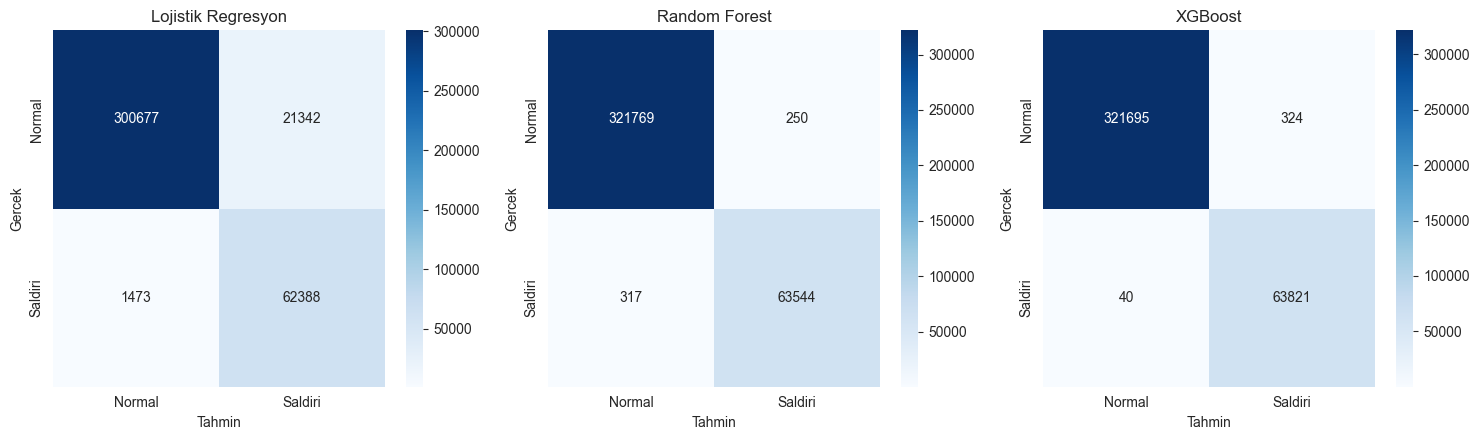

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, models.keys()):
    y_pred, _ = predictions[name]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Saldiri'], yticklabels=['Normal', 'Saldiri'])
    ax.set_title(name)
    ax.set_xlabel('Tahmin')
    ax.set_ylabel('Gercek')
plt.tight_layout()
plt.savefig('../results/figures/binary_confusion_matrices.png', dpi=150)
plt.show()

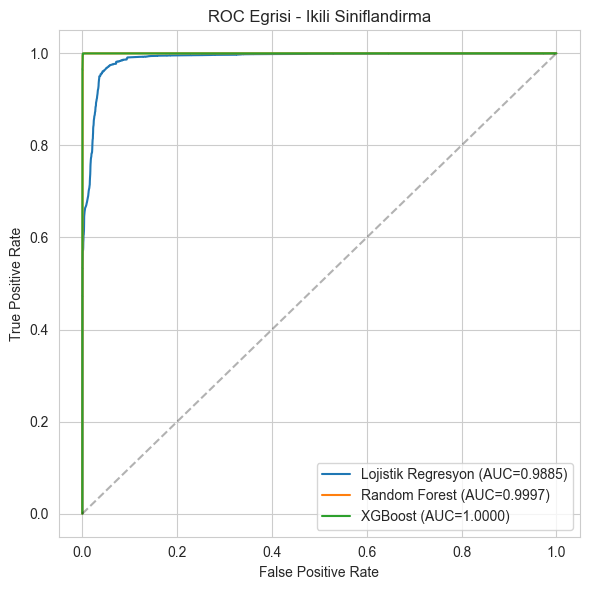

In [6]:
plt.figure(figsize=(6, 6))
for name in models.keys():
    _, y_proba = predictions[name]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={results[name]["roc_auc"]:.4f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.3)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Egrisi - Ikili Siniflandirma')
plt.legend()
plt.tight_layout()
plt.savefig('../results/figures/binary_roc_curve.png', dpi=150)
plt.show()

## 4. Özellik önemi (Feature Importance)

Random Forest ve XGBoost için en önemli 15 özellik. Bu, "model neye bakarak karar veriyor?" sorusuna cevap verir ve ağ güvenliği açısından anlamlı olup olmadığını değerlendirmemizi sağlar.

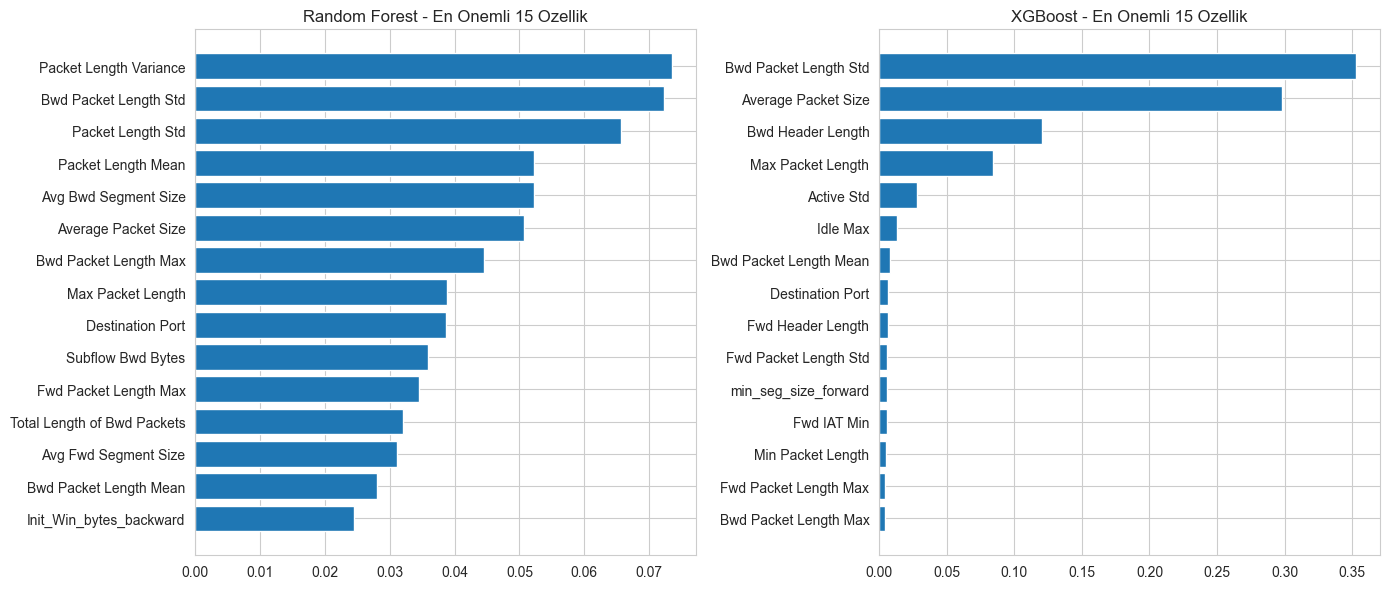

XGBoost en onemli 5 ozellik:
Bwd Packet Length Std    0.352971
Average Packet Size      0.298357
Bwd Header Length        0.120248
Max Packet Length        0.083933
Active Std               0.027704
dtype: float32


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
importances = {}
for ax, name in zip(axes, ['Random Forest', 'XGBoost']):
    clf = trained_models[name].named_steps['clf']
    imp = pd.Series(clf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(15)
    importances[name] = imp
    ax.barh(imp.index[::-1], imp.values[::-1])
    ax.set_title(f'{name} - En Onemli 15 Ozellik')
plt.tight_layout()
plt.savefig('../results/figures/binary_feature_importance.png', dpi=150)
plt.show()

print('XGBoost en onemli 5 ozellik:')
print(importances['XGBoost'].head(5))

**Özelliklerin ağ güvenliği açısından anlamı** (XGBoost'un gerçek en önemli 5 özelliği, yukarıdaki grafikten):
- **Bwd Packet Length Std:** Sunucudan istemciye giden paketlerin boyutundaki değişkenlik. Normal bir web/dosya transferinde paket boyutları çeşitlenirken, DoS veya port tarama araçlarının ürettiği tekdüze/küçük paketlerde bu sapma çok düşük kalır.
- **Average Packet Size:** EDA'da da gördüğümüz gibi saldırı akışlarının ortalama paket boyutu normale göre çok küçük — taşınan gerçek veri az, çoğunlukla protokol/keşif amaçlı trafik.
- **Bwd Header Length:** Geri yöndeki toplam TCP/IP başlık baytı; veri taşımayan veya çok az veri taşıyan (SYN/ACK ağırlıklı, port tarama gibi) akışlarda header oranı orantısız yüksek kalır.
- **Max Packet Length:** Akıştaki en büyük paketin boyutu; normal içerik transferinde büyük paketler görülürken, tarama/keşif trafiğinde paketler hep küçük kalır.
- **Active Std:** Akışın "aktif" (veri alışverişi olan) sürelerindeki değişkenlik; otomatikleştirilmiş saldırı araçlarının düzenli/tekdüze zamanlama örüntüsü, insan kaynaklı normal trafikten ayrışır.

**Destination Port** her iki modelde de listede yer alsa da toplam önemin sadece küçük bir kısmını taşıyor (bkz. aşağıdaki sızıntı kontrolü) — yani model belirli portları ezberlemek yerine gerçekten trafiğin şekline (paket boyutu, zamanlama, header oranı) bakarak karar veriyor. Bu, modelin farklı bir ağda/farklı portlarda çalışan saldırılara da genellenme ihtimalini artıran olumlu bir bulgu.

## 5. Destination Port hassasiyeti: sızıntı riski kontrolü

`Destination Port` feature importance'ta ne kadar baskın? Eğer XGBoost'un toplam öneminin büyük kısmını tek başına taşıyorsa, bu özelliği çıkarıp modeli yeniden eğitip farkı raporluyoruz — CLAUDE.md'nin özellikle işaret ettiği bir kontrol noktası.

In [8]:
port_share = importances['XGBoost'].get('Destination Port', 0) / trained_models['XGBoost'].named_steps['clf'].feature_importances_.sum()
print(f"Destination Port, XGBoost toplam oneminin %{100*port_share:.1f}'ini olusturuyor.")

if port_share > 0.30:
    print('Esik asildi (%30) -> Destination Port CIKARILARAK yeniden egitiliyor...')
    feature_cols_no_port = [c for c in feature_cols if c != 'Destination Port']
    pipe_no_port = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', XGBClassifier(scale_pos_weight=scale_pos_weight, n_estimators=200, max_depth=6,
                               tree_method='hist', eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)),
    ])
    pipe_no_port.fit(X_train[feature_cols_no_port], y_train)
    y_pred_no_port = pipe_no_port.predict(X_test[feature_cols_no_port])
    f1_no_port = f1_score(y_test, y_pred_no_port)
    print(f"Destination Port DAHIL F1: {results['XGBoost']['f1']:.4f}")
    print(f"Destination Port HARIC F1: {f1_no_port:.4f}")
else:
    print('Esik asilmadi -> Destination Port dahil edilmeye devam ediliyor, ek deney gerekmiyor.')

Destination Port, XGBoost toplam oneminin %0.7'ini olusturuyor.
Esik asilmadi -> Destination Port dahil edilmeye devam ediliyor, ek deney gerekmiyor.


## 6. En iyi modeli kaydet

In [9]:
best_name = results_df['f1'].idxmax()
print(f'En iyi model (F1 skoruna gore): {best_name}')

import os
os.makedirs('../models', exist_ok=True)
joblib.dump({
    'pipeline': trained_models[best_name],
    'feature_columns': feature_cols,
    'model_name': best_name,
}, '../models/binary_best_model.joblib')
print('Kaydedildi: models/binary_best_model.joblib')

En iyi model (F1 skoruna gore): XGBoost
Kaydedildi: models/binary_best_model.joblib
